# Week 6: Decision Trees and Random Forests

In this notebook, I apply Week 6 concepts to my capstone datasets using decision tree and random forest models. Decision trees make predictions by splitting the data into a sequence of decisions, while random forests combine many decision trees to reduce overfitting and improve generalization.

The main goals of this notebook are to:

1. Train decision tree models on the diabetes and Alzheimer’s datasets.
2. Compare unrestricted and controlled decision trees using parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf`.
3. Train random forest models and compare their performance to single decision trees.
4. Examine feature importance to understand which variables are most influential.
5. Connect the results back to chronic disease prediction and the Week 6 lesson concepts.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [3]:
diabetes_df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
alzheimers_df = pd.read_csv("alzheimers_disease_data.csv")

print("Diabetes dataset shape:", diabetes_df.shape)
print("Alzheimer's dataset shape:", alzheimers_df.shape)

Diabetes dataset shape: (253680, 22)
Alzheimer's dataset shape: (2149, 35)


In [4]:
display(diabetes_df.head())
display(alzheimers_df.head())

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


## Preparing the Data

For the diabetes dataset, the target variable is `Diabetes_012`, which represents three classification categories. For the Alzheimer's dataset, the target variable is `Diagnosis`, which is also a classification target.

Before building decision tree and random forest models, I separate each dataset into features `X` and target values `y`. I also remove ID or non-predictive columns from the Alzheimer's dataset, such as `PatientID` and `DoctorInCharge`.

In [5]:
X_diabetes = diabetes_df.drop("Diabetes_012", axis=1)
y_diabetes = diabetes_df["Diabetes_012"]

X_alzheimers = alzheimers_df.drop(["Diagnosis", "PatientID", "DoctorInCharge"], axis=1)
y_alzheimers = alzheimers_df["Diagnosis"]

print("Diabetes features shape:", X_diabetes.shape)
print("Diabetes target shape:", y_diabetes.shape)

print("Alzheimer's features shape:", X_alzheimers.shape)
print("Alzheimer's target shape:", y_alzheimers.shape)

Diabetes features shape: (253680, 21)
Diabetes target shape: (253680,)
Alzheimer's features shape: (2149, 32)
Alzheimer's target shape: (2149,)


In [6]:
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.2,
    random_state=42,
    stratify=y_diabetes
)

X_train_alzheimers, X_test_alzheimers, y_train_alzheimers, y_test_alzheimers = train_test_split(
    X_alzheimers,
    y_alzheimers,
    test_size=0.2,
    random_state=42,
    stratify=y_alzheimers
)

print("Diabetes training set:", X_train_diabetes.shape)
print("Diabetes testing set:", X_test_diabetes.shape)

print("Alzheimer's training set:", X_train_alzheimers.shape)
print("Alzheimer's testing set:", X_test_alzheimers.shape)

Diabetes training set: (202944, 21)
Diabetes testing set: (50736, 21)
Alzheimer's training set: (1719, 32)
Alzheimer's testing set: (430, 32)


In [7]:
print("Diabetes class distribution:")
display(y_diabetes.value_counts(normalize=True).sort_index())

print("Alzheimer's class distribution:")
display(y_alzheimers.value_counts(normalize=True).sort_index())

Diabetes class distribution:


Diabetes_012
0.0    0.842412
1.0    0.018255
2.0    0.139333
Name: proportion, dtype: float64

Alzheimer's class distribution:


Diagnosis
0    0.646347
1    0.353653
Name: proportion, dtype: float64

In [8]:
dt_diabetes = DecisionTreeClassifier(random_state=42)
dt_diabetes.fit(X_train_diabetes, y_train_diabetes)

dt_alzheimers = DecisionTreeClassifier(random_state=42)
dt_alzheimers.fit(X_train_alzheimers, y_train_alzheimers)

print("Decision tree models trained successfully.")

Decision tree models trained successfully.


In [9]:
y_pred_dt_diabetes = dt_diabetes.predict(X_test_diabetes)
y_pred_dt_alzheimers = dt_alzheimers.predict(X_test_alzheimers)

print("Diabetes Decision Tree Accuracy:", accuracy_score(y_test_diabetes, y_pred_dt_diabetes))
print("Alzheimer's Decision Tree Accuracy:", accuracy_score(y_test_alzheimers, y_pred_dt_alzheimers))

Diabetes Decision Tree Accuracy: 0.7667730999684642
Alzheimer's Decision Tree Accuracy: 0.9


In [10]:
print("Diabetes Decision Tree Classification Report:")
print(classification_report(y_test_diabetes, y_pred_dt_diabetes))

print("Alzheimer's Decision Tree Classification Report:")
print(classification_report(y_test_alzheimers, y_pred_dt_alzheimers))

Diabetes Decision Tree Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.86      0.87     42741
         1.0       0.03      0.04      0.03       926
         2.0       0.30      0.33      0.31      7069

    accuracy                           0.77     50736
   macro avg       0.40      0.41      0.40     50736
weighted avg       0.78      0.77      0.77     50736

Alzheimer's Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       278
           1       0.85      0.88      0.86       152

    accuracy                           0.90       430
   macro avg       0.89      0.89      0.89       430
weighted avg       0.90      0.90      0.90       430



In [11]:
print("Diabetes Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test_diabetes, y_pred_dt_diabetes))

print("Alzheimer's Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test_alzheimers, y_pred_dt_alzheimers))

Diabetes Decision Tree Confusion Matrix:
[[36570   904  5267]
 [  668    35   223]
 [ 4479   292  2298]]
Alzheimer's Decision Tree Confusion Matrix:
[[254  24]
 [ 19 133]]


### Initial Decision Tree Results

The basic diabetes decision tree reached about 76.7% accuracy. This is lower than the earlier logistic regression model, but the confusion matrix shows that the tree at least attempts to classify all three diabetes categories. The model still struggles badly with class `1.0`, which is the smallest class in the dataset. This suggests that class imbalance remains a major issue.

The Alzheimer’s decision tree performed much better, with about 90% accuracy. The confusion matrix shows that the model correctly classified most patients in both diagnosis groups. Compared with the diabetes dataset, the Alzheimer’s target is more balanced, which may help the decision tree perform more consistently across classes.

Because unrestricted decision trees can overfit, the next step is to control tree complexity using parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf`.

In [12]:
print("Diabetes Decision Tree Train Accuracy:", dt_diabetes.score(X_train_diabetes, y_train_diabetes))
print("Diabetes Decision Tree Test Accuracy:", dt_diabetes.score(X_test_diabetes, y_test_diabetes))

print("Alzheimer's Decision Tree Train Accuracy:", dt_alzheimers.score(X_train_alzheimers, y_train_alzheimers))
print("Alzheimer's Decision Tree Test Accuracy:", dt_alzheimers.score(X_test_alzheimers, y_test_alzheimers))

Diabetes Decision Tree Train Accuracy: 0.993264151687165
Diabetes Decision Tree Test Accuracy: 0.7667730999684642
Alzheimer's Decision Tree Train Accuracy: 1.0
Alzheimer's Decision Tree Test Accuracy: 0.9


### Overfitting in the Basic Decision Trees

The training accuracy is much higher than the testing accuracy for both datasets. The diabetes decision tree reached about 99.3% accuracy on the training data but only about 76.7% accuracy on the test data. The Alzheimer’s decision tree reached 100% training accuracy but dropped to about 90% test accuracy.

This shows that unrestricted decision trees can overfit by learning very specific patterns in the training set. This connects directly to the Week 6 lesson because decision trees can continue splitting until they create highly specific leaf nodes. To reduce overfitting, the next models will control the tree using `max_depth`, `min_samples_split`, and `min_samples_leaf`.

In [14]:
dt_diabetes_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42
)

dt_alzheimers_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_diabetes_tuned.fit(X_train_diabetes, y_train_diabetes)
dt_alzheimers_tuned.fit(X_train_alzheimers, y_train_alzheimers)

print("Controlled decision tree models trained successfully.")

Controlled decision tree models trained successfully.


In [15]:
y_pred_dt_diabetes_tuned = dt_diabetes_tuned.predict(X_test_diabetes)
y_pred_dt_alzheimers_tuned = dt_alzheimers_tuned.predict(X_test_alzheimers)

print("Diabetes Controlled Decision Tree Train Accuracy:", dt_diabetes_tuned.score(X_train_diabetes, y_train_diabetes))
print("Diabetes Controlled Decision Tree Test Accuracy:", accuracy_score(y_test_diabetes, y_pred_dt_diabetes_tuned))

print("Alzheimer's Controlled Decision Tree Train Accuracy:", dt_alzheimers_tuned.score(X_train_alzheimers, y_train_alzheimers))
print("Alzheimer's Controlled Decision Tree Test Accuracy:", accuracy_score(y_test_alzheimers, y_pred_dt_alzheimers_tuned))

Diabetes Controlled Decision Tree Train Accuracy: 0.8479432749921161
Diabetes Controlled Decision Tree Test Accuracy: 0.8470711132134974
Alzheimer's Controlled Decision Tree Train Accuracy: 0.9552065154159395
Alzheimer's Controlled Decision Tree Test Accuracy: 0.9488372093023256


### Controlled Decision Tree Results

After limiting tree complexity with `max_depth`, `min_samples_split`, and `min_samples_leaf`, the decision tree models generalized better.

For the diabetes dataset, the controlled decision tree had nearly the same training and testing accuracy. This suggests that the model was no longer memorizing the training data as strongly as the unrestricted tree. However, because the diabetes target is highly imbalanced, accuracy should still be interpreted carefully.

For the Alzheimer’s dataset, the controlled decision tree improved test accuracy from about 90% to about 94.9%. This suggests that reducing overfitting helped the model capture more meaningful patterns instead of overly specific training examples.

In [16]:
print("Diabetes Controlled Decision Tree Classification Report:")
print(classification_report(y_test_diabetes, y_pred_dt_diabetes_tuned))

print("Alzheimer's Controlled Decision Tree Classification Report:")
print(classification_report(y_test_alzheimers, y_pred_dt_alzheimers_tuned))

Diabetes Controlled Decision Tree Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.55      0.13      0.21      7069

    accuracy                           0.85     50736
   macro avg       0.47      0.37      0.38     50736
weighted avg       0.80      0.85      0.80     50736

Alzheimer's Controlled Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       278
           1       0.93      0.92      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [17]:
print("Diabetes Controlled Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test_diabetes, y_pred_dt_diabetes_tuned))

print("Alzheimer's Controlled Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test_alzheimers, y_pred_dt_alzheimers_tuned))

Diabetes Controlled Decision Tree Confusion Matrix:
[[42063     0   678]
 [  859     0    67]
 [ 6155     0   914]]
Alzheimer's Controlled Decision Tree Confusion Matrix:
[[268  10]
 [ 12 140]]


### Controlled Tree Classification Performance

The controlled diabetes decision tree improved overall accuracy to about 84.7%, but the classification report shows that this improvement mostly came from predicting the majority class more often. The model did not correctly identify class `1.0`, and recall for class `2.0` was still low. This shows why accuracy alone can be misleading for imbalanced healthcare datasets.

The Alzheimer’s controlled decision tree performed much better across both classes. Precision and recall were high for both diagnosis groups, which suggests that the model learned more balanced decision rules for this dataset.

The warning in the diabetes classification report occurred because the model did not predict any samples as class `1.0`. This is another sign that the class imbalance affects model performance.

## Random Forest Models

Random forests build many decision trees and combine their predictions. For classification, the final prediction is based on the most common class predicted by the trees. This helps reduce overfitting because each tree is trained with randomness, including random feature selection at different splits.

In [18]:
rf_diabetes = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42,
    n_jobs=-1
)

rf_alzheimers = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_diabetes.fit(X_train_diabetes, y_train_diabetes)
rf_alzheimers.fit(X_train_alzheimers, y_train_alzheimers)

print("Random forest models trained successfully.")

Random forest models trained successfully.


In [19]:
y_pred_rf_diabetes = rf_diabetes.predict(X_test_diabetes)
y_pred_rf_alzheimers = rf_alzheimers.predict(X_test_alzheimers)

print("Diabetes Random Forest Train Accuracy:", rf_diabetes.score(X_train_diabetes, y_train_diabetes))
print("Diabetes Random Forest Test Accuracy:", accuracy_score(y_test_diabetes, y_pred_rf_diabetes))

print("Alzheimer's Random Forest Train Accuracy:", rf_alzheimers.score(X_train_alzheimers, y_train_alzheimers))
print("Alzheimer's Random Forest Test Accuracy:", accuracy_score(y_test_alzheimers, y_pred_rf_alzheimers))

Diabetes Random Forest Train Accuracy: 0.8481995033112583
Diabetes Random Forest Test Accuracy: 0.8471105329549038
Alzheimer's Random Forest Train Accuracy: 0.9569517161140197
Alzheimer's Random Forest Test Accuracy: 0.9348837209302325


In [20]:
print("Diabetes Random Forest Classification Report:")
print(classification_report(y_test_diabetes, y_pred_rf_diabetes))

print("Alzheimer's Random Forest Classification Report:")
print(classification_report(y_test_alzheimers, y_pred_rf_alzheimers))

Diabetes Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.99      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.61      0.08      0.14      7069

    accuracy                           0.85     50736
   macro avg       0.49      0.36      0.35     50736
weighted avg       0.80      0.85      0.79     50736

Alzheimer's Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       278
           1       0.95      0.86      0.90       152

    accuracy                           0.93       430
   macro avg       0.94      0.92      0.93       430
weighted avg       0.94      0.93      0.93       430



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [21]:
print("Diabetes Random Forest Confusion Matrix:")
print(confusion_matrix(y_test_diabetes, y_pred_rf_diabetes))

print("Alzheimer's Random Forest Confusion Matrix:")
print(confusion_matrix(y_test_alzheimers, y_pred_rf_alzheimers))

Diabetes Random Forest Confusion Matrix:
[[42414     0   327]
 [  892     0    34]
 [ 6504     0   565]]
Alzheimer's Random Forest Confusion Matrix:
[[271   7]
 [ 21 131]]


### Random Forest Results

The diabetes random forest reached about 84.7% test accuracy, which is almost identical to the controlled decision tree. However, the classification report and confusion matrix show that the model still failed to predict class `1.0`. It also had low recall for class `2.0`. This means the high accuracy is mostly driven by the majority class, not by balanced performance across all diabetes categories.

The Alzheimer’s random forest performed well, with about 93.5% test accuracy. It correctly identified most patients in both diagnosis groups, although it performed slightly worse than the controlled decision tree. Overall, the random forest showed strong generalization, but it did not clearly outperform the simpler controlled tree on this dataset.

These results show that random forests can reduce overfitting, but they do not automatically solve class imbalance.

In [22]:
model_results = pd.DataFrame({
    "Dataset": [
        "Diabetes",
        "Diabetes",
        "Diabetes",
        "Alzheimer's",
        "Alzheimer's",
        "Alzheimer's"
    ],
    "Model": [
        "Decision Tree",
        "Controlled Decision Tree",
        "Random Forest",
        "Decision Tree",
        "Controlled Decision Tree",
        "Random Forest"
    ],
    "Train Accuracy": [
        dt_diabetes.score(X_train_diabetes, y_train_diabetes),
        dt_diabetes_tuned.score(X_train_diabetes, y_train_diabetes),
        rf_diabetes.score(X_train_diabetes, y_train_diabetes),
        dt_alzheimers.score(X_train_alzheimers, y_train_alzheimers),
        dt_alzheimers_tuned.score(X_train_alzheimers, y_train_alzheimers),
        rf_alzheimers.score(X_train_alzheimers, y_train_alzheimers)
    ],
    "Test Accuracy": [
        accuracy_score(y_test_diabetes, y_pred_dt_diabetes),
        accuracy_score(y_test_diabetes, y_pred_dt_diabetes_tuned),
        accuracy_score(y_test_diabetes, y_pred_rf_diabetes),
        accuracy_score(y_test_alzheimers, y_pred_dt_alzheimers),
        accuracy_score(y_test_alzheimers, y_pred_dt_alzheimers_tuned),
        accuracy_score(y_test_alzheimers, y_pred_rf_alzheimers)
    ]
})

model_results

,Dataset,Model,Train Accuracy,Test Accuracy
0,Diabetes,Decision Tree,0.993264,0.766773
1,Diabetes,Controlled Decision Tree,0.847943,0.847071
2,Diabetes,Random Forest,0.848200,0.847111
3,Alzheimer's,Decision Tree,1.000000,0.900000
4,Alzheimer's,Controlled Decision Tree,0.955207,0.948837
5,Alzheimer's,Random Forest,0.956952,0.934884


### Model Comparison

The summary table shows that the unrestricted decision trees overfit both datasets. For diabetes, the basic decision tree had about 99.3% training accuracy but only about 76.7% testing accuracy. For Alzheimer’s, the basic decision tree had 100% training accuracy but only 90% testing accuracy.

The controlled decision trees reduced this gap. The diabetes controlled tree had nearly identical training and testing accuracy, which suggests better generalization. The Alzheimer’s controlled tree performed the best overall, with about 94.9% test accuracy.

The random forest models also reduced overfitting, but they did not outperform the controlled decision tree in this notebook. For diabetes, random forest performance was almost identical to the controlled tree. For Alzheimer’s, the random forest performed slightly worse than the controlled decision tree.

Overall, controlling tree depth and leaf size was important for reducing overfitting.

## Feature Importance

Decision trees and random forests can estimate feature importance by tracking which features are most useful for splitting the data. This helps show which variables contributed most to the model's predictions.

In [23]:
diabetes_importance = pd.DataFrame({
    "Feature": X_diabetes.columns,
    "Importance": rf_diabetes.feature_importances_
}).sort_values(by="Importance", ascending=False)

alzheimers_importance = pd.DataFrame({
    "Feature": X_alzheimers.columns,
    "Importance": rf_alzheimers.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top Diabetes Feature Importances:")
display(diabetes_importance.head(10))

print("Top Alzheimer's Feature Importances:")
display(alzheimers_importance.head(10))

Top Diabetes Feature Importances:


,Feature,Importance
13,GenHlth,0.223377
0,HighBP,0.218044
3,BMI,0.161925
1,HighChol,0.108574
16,DiffWalk,0.078369
18,Age,0.063214
6,HeartDiseaseorAttack,0.039581
15,PhysHlth,0.033531
20,Income,0.025912
7,PhysActivity,0.010497


Top Alzheimer's Feature Importances:


,Feature,Importance
23,FunctionalAssessment,0.241861
26,ADL,0.207353
22,MMSE,0.148680
24,MemoryComplaints,0.125341
25,BehavioralProblems,0.064047
8,DietQuality,0.017655
4,BMI,0.017398
20,CholesterolHDL,0.017176
21,CholesterolTriglycerides,0.016911
7,PhysicalActivity,0.016906


### Feature Importance Results

For the diabetes random forest, the most important features were `GenHlth`, `HighBP`, `BMI`, `HighChol`, `DiffWalk`, and `Age`. These results make sense because general health, blood pressure, body mass index, cholesterol, mobility difficulty, and age are all closely related to diabetes risk.

For the Alzheimer’s random forest, the most important features were `FunctionalAssessment`, `ADL`, `MMSE`, `MemoryComplaints`, and `BehavioralProblems`. These features are directly related to cognitive functioning, daily living ability, and symptoms associated with Alzheimer’s diagnosis.

The feature importance results help make the random forest models more interpretable. Even though random forests are harder to visualize than a single decision tree, feature importance shows which variables were most influential in the model’s decisions.

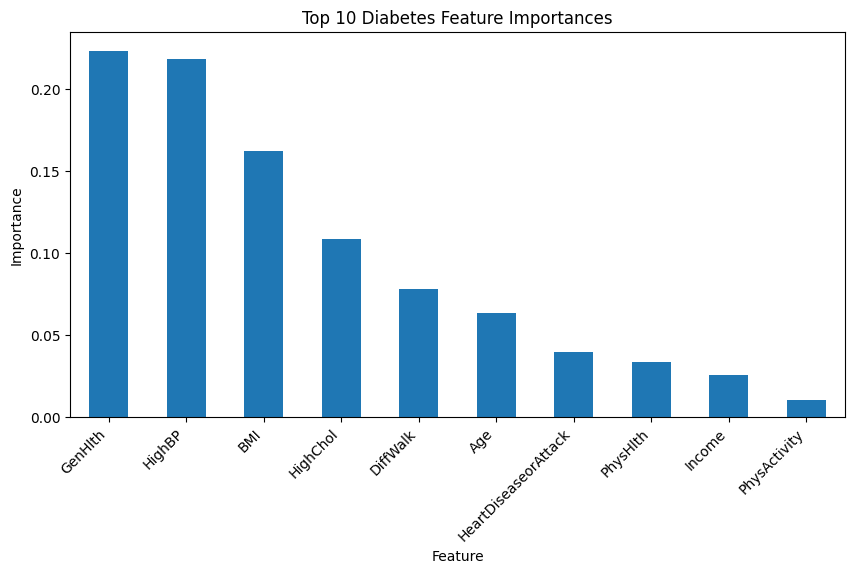

In [24]:
diabetes_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(10, 5),
    title="Top 10 Diabetes Feature Importances"
)

plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()

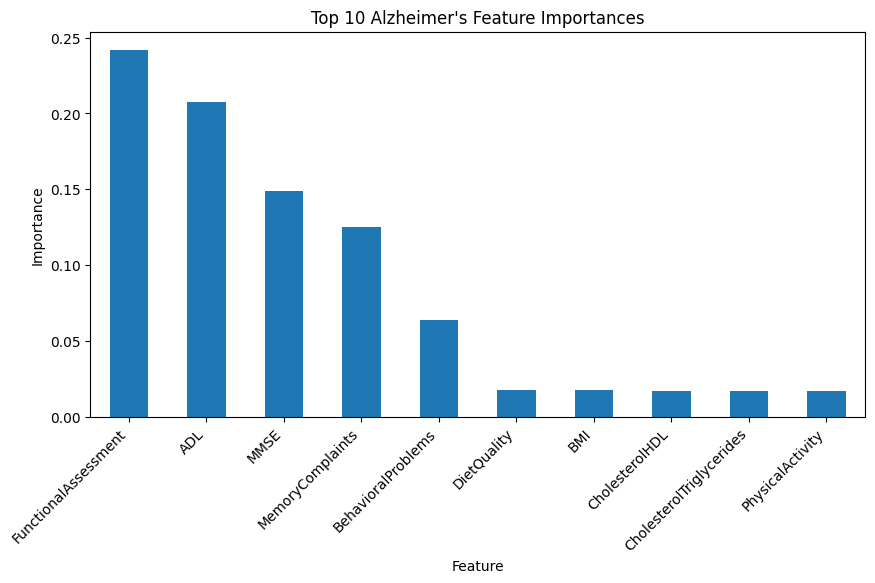

In [25]:
alzheimers_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(10, 5),
    title="Top 10 Alzheimer's Feature Importances"
)

plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()

## Week 6 Conclusion

In this notebook, I applied decision tree and random forest models to both the diabetes and Alzheimer’s datasets. The results showed that unrestricted decision trees can easily overfit. Both datasets had very high training accuracy with the basic decision tree models, but the testing accuracy was noticeably lower.

After controlling tree complexity with `max_depth`, `min_samples_split`, and `min_samples_leaf`, the models generalized better. The controlled diabetes decision tree had nearly identical training and testing accuracy, while the controlled Alzheimer’s decision tree achieved the best overall test accuracy.

The random forest models also reduced overfitting by combining many decision trees and using random feature selection. However, the random forests did not clearly outperform the controlled decision trees in this notebook. For diabetes, both models had similar accuracy, but both struggled with the minority diabetes classes. For Alzheimer’s, the random forest performed well but slightly below the controlled decision tree.

Feature importance helped connect the models back to the health prediction problem. For diabetes, the most important features included general health, high blood pressure, BMI, cholesterol, difficulty walking, and age. For Alzheimer’s, the most important features were functional assessment, activities of daily living, MMSE, memory complaints, and behavioral problems.

Overall, Week 6 showed that tree-based models are useful for capturing nonlinear patterns and identifying influential features, but they still require controls to prevent overfitting. The diabetes results also show that class imbalance remains an important limitation, even when using random forests.

In [26]:
model_results

,Dataset,Model,Train Accuracy,Test Accuracy
0,Diabetes,Decision Tree,0.993264,0.766773
1,Diabetes,Controlled Decision Tree,0.847943,0.847071
2,Diabetes,Random Forest,0.848200,0.847111
3,Alzheimer's,Decision Tree,1.000000,0.900000
4,Alzheimer's,Controlled Decision Tree,0.955207,0.948837
5,Alzheimer's,Random Forest,0.956952,0.934884
